# Visualize Torch Sliding Dataset

Loads the saved PyTorch Dataset created by prepare_dataset.py and visualizes input patches with their label masks using the class colors from config.

In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch

import config

In [2]:
# Locate dataset outputs (default from prepare_dataset.py)
module_dir = Path.cwd()
dataset_path = module_dir / "big_data" / "dataset" / "torch_sliding_dataset.pt"
metadata_path = module_dir / "big_data" / "dataset" / "torch_sliding_dataset_metadata.pt"

# Fallback to root-level files produced from trial notebook
if not dataset_path.exists():
    dataset_path = module_dir / "torch_sliding_dataset.pt"
if not metadata_path.exists():
    metadata_path = module_dir / "torch_sliding_dataset_metadata.pt"

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

torch_dataset = torch.load(dataset_path, weights_only=False)
window_meta = torch.load(metadata_path, weights_only=False) if metadata_path.exists() else []

print(f"Loaded dataset: {dataset_path}")
print(f"Dataset type: {type(torch_dataset).__name__}")
print(f"Dataset length: {len(torch_dataset)}")
if len(torch_dataset) > 0:
    x0, y0 = torch_dataset[0]
    print(f"Sample input shape: {tuple(x0.shape)}")
    print(f"Sample label shape: {tuple(y0.shape)}")
print(f"Metadata rows: {len(window_meta)}")

Loaded dataset: /opt/watchdog/users/cerussite/alok/work/landsat_download/torch_sliding_dataset.pt
Dataset type: TensorDataset
Dataset length: 2703
Sample input shape: (7, 32, 32)
Sample label shape: (32, 32)
Metadata rows: 2703


In [3]:
def stretch_percentile(channel: np.ndarray, low: float = 2.0, high: float = 98.0) -> np.ndarray:
    channel = channel.astype(np.float32)
    p_low, p_high = np.percentile(channel, [low, high])
    if p_high <= p_low:
        return np.zeros_like(channel, dtype=np.float32)
    return np.clip((channel - p_low) / (p_high - p_low), 0, 1)

# Build label colormap from config.ESRI_CLASSES
max_class = max(config.ESRI_CLASSES.keys())
color_list = ["#000000"] * (max_class + 1)
for class_val, (_, hex_color) in config.ESRI_CLASSES.items():
    color_list[class_val] = hex_color

label_cmap = ListedColormap(color_list)
label_norm = BoundaryNorm(np.arange(-0.5, max_class + 1.5, 1), label_cmap.N)
legend_patches = [
    mpatches.Patch(color=hex_color, label=f"{class_val}: {name}")
    for class_val, (name, hex_color) in sorted(config.ESRI_CLASSES.items())
    if class_val != 0
]

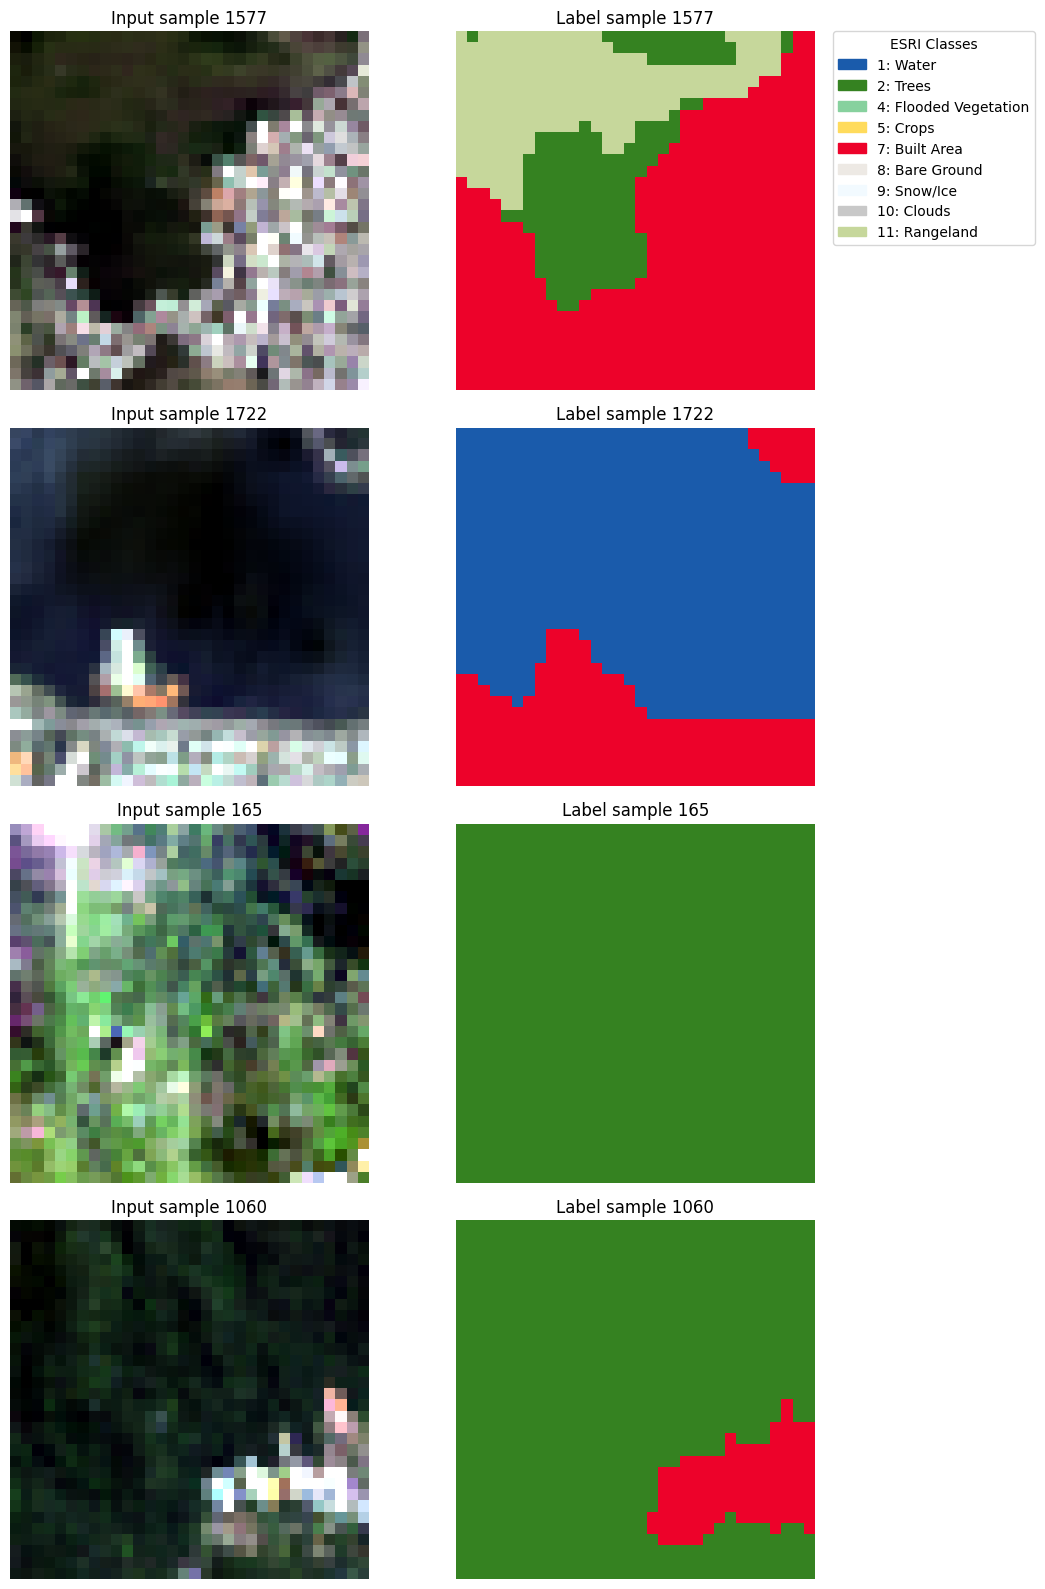

In [5]:
# Visualize a few random samples: input RGB (B4/B3/B2) and output label map
num_examples = 4
seed = 0
random.seed(seed)

n = len(torch_dataset)
if n == 0:
    raise ValueError("Dataset is empty.")

indices = random.sample(range(n), k=min(num_examples, n))

fig, axes = plt.subplots(len(indices), 2, figsize=(12, 4 * len(indices)))
if len(indices) == 1:
    axes = np.array([axes])

for i, idx in enumerate(indices):
    x_patch, y_patch = torch_dataset[idx]
    x_np = x_patch.detach().cpu().numpy()
    y_np = y_patch.detach().cpu().numpy()

    if y_np.ndim == 3 and y_np.shape[0] == 1:
        y_np = y_np[0]

    if x_np.shape[0] >= 3:
        # Landsat order from prepare_dataset.py is B2,B3,B4,... so RGB uses [2,1,0]
        rgb = np.dstack([
            stretch_percentile(x_np[2]),
            stretch_percentile(x_np[1]),
            stretch_percentile(x_np[0]),
        ])
    else:
        gray = stretch_percentile(x_np[0])
        rgb = np.dstack([gray, gray, gray])

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Input sample {idx}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_np, cmap=label_cmap, norm=label_norm)
    axes[i, 1].set_title(f"Label sample {idx}")
    axes[i, 1].axis("off")

axes[0, 1].legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
    title="ESRI Classes",
)

plt.tight_layout()
plt.show()